## DERIVATIVE PRICING
MODULE 5 | LESSON 1


---



# **WORKING WITH STOCK RETURNS**


|  |  |
|:---|:---|
|**Reading Time** |  55 minutes |
|**Prior Knowledge** | Financial time series, Stock returns |
|**Keywords** | Financial data, Historical stock returns, ETFs, Compounding |


---

*In this lesson, we are going to introduce some basic features for downloading, treating, and working with financial data in practice. These are practices we will be using for the remainder of the course (as well as in the Stochastic Modeling course), so make sure you understand the different issues!*

*There are two main topics that we will cover in this notebook:*

- *How to work with financial data (stock prices) in Python.*

- *How to calculate, treat, and work with stock return data in practice.*

*Let's start with the first topic on reading financial data.*<span style='color: transparent; font-size:1%'>All rights reserved WQU WorldQuant University</span>

## 1. Introduction to Financial Data and Returns

In this section, we introduce how to work with financial data using real historical prices from equities and ETFs (Exchange-Traded Funds). 
Instead of relying on unstable APIs, we use data stored in CSV files, which is a common and reliable method for reproducible analysis.

We will work with the following tickers:

- **SPY**: ETF tracking the S&P 500 Index (large-cap U.S. equities).
- **IWM**: ETF tracking the Russell 2000 Index (small-cap U.S. equities).
- **KO**: Stock of The Coca-Cola Company (consumer staples sector).
- **TSLA**: Stock of Tesla, Inc. (automotive and technology sector).

We will load the data, visualize prices, and compute returns as a first step in derivative pricing models.




In [1]:
# Load necessary libraries
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Load data from CSV files
spy = pd.read_csv('SPY_wqu_data.csv', parse_dates=['timestamp'])
iwm = pd.read_csv('IWM_wqu_data.csv', parse_dates=['timestamp'])
ko = pd.read_csv('KO_wqu_data.csv', parse_dates=['timestamp'])
tsla = pd.read_csv('TSLA_wqu_data.csv', parse_dates=['timestamp'])

In [3]:
for df in [spy, iwm, ko, tsla]:
    df.set_index('timestamp', inplace=True)
    df.sort_index(inplace=True)

#### Understanding the Financial Data Structure

Before diving into returns and pricing models, it's important to understand the structure of the data we are working with.

Let’s take a closer look at the SPY dataset, which contains historical prices of the SPY ETF (tracking the S&P 500 Index). The dataset includes daily price and volume information.

In [4]:
# Display the first few rows of SPY data
spy.head()

,volume,vw,open,close,high,low,transactions
timestamp,,,,,,,
2003-09-10 04:00:00,45417600.0,102.2064,102.530,101.96,102.80,101.55,25951
2003-09-11 04:00:00,38038300.0,102.3182,102.100,102.26,102.76,101.84,22580
2003-09-12 04:00:00,41159600.0,101.9165,101.910,102.45,102.64,101.35,26091
2003-09-15 04:00:00,20710600.0,102.2676,102.520,102.09,102.63,101.95,15670
2003-09-16 04:00:00,37103300.0,103.0466,102.232,103.58,103.64,102.17,19074


Here is a brief explanation of each column in the dataset:

- **open**: Price at which the ETF first traded when the market opened on that day.
- **close** *(adjusted close)*: The final trading price of the day, adjusted for events like dividends and stock splits. This adjustment ensures that historical price comparisons remain meaningful over time.
- **high**: The highest price reached during the trading session.
- **low**: The lowest price reached during the trading session.
- **vw** (volume-weighted average price): An average price weighted by the trading volume throughout the day. It reflects the true average transaction price.
- **volume**: Total number of shares traded on that day.
- **transactions**: Number of individual trades that occurred during the day.

> ⚠️ **Important:** In this dataset, the `close` column already reflects **adjusted close** prices. This is crucial for return calculations, as it accounts for dividends and splits, giving us a more accurate picture of the asset's performance over time.

Now, let's start by plotting the historical closing prices (adjusted for splits and dividends) for SPY, KO, and IWM.

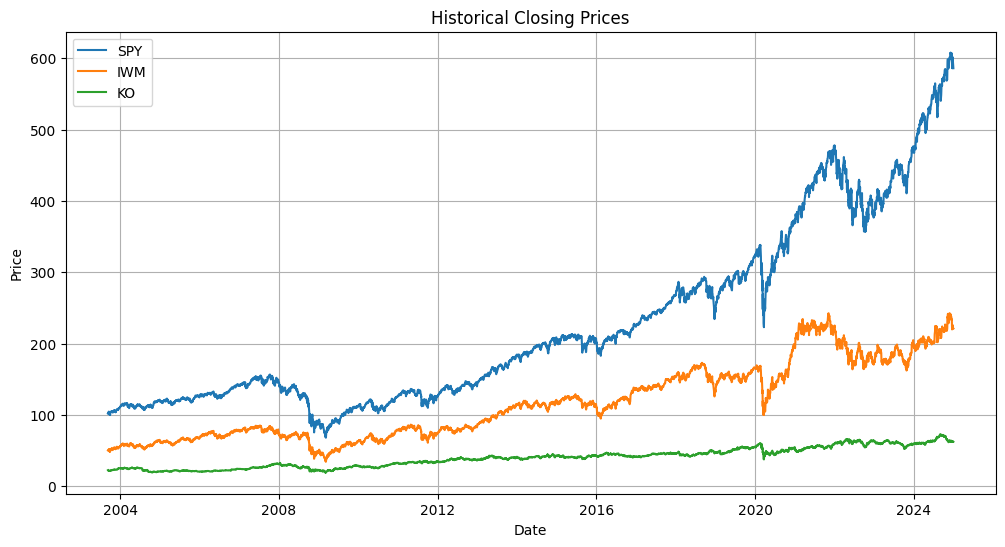

In [5]:
plt.figure(figsize=(12, 6))
plt.plot(spy['close'], label='SPY')
plt.plot(iwm['close'], label='IWM')
plt.plot(ko['close'], label='KO')
plt.title('Historical Closing Prices')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

Since TSLA stock has less historical data available, we conclude this simple exercise by plotting its adjusted closing prices.

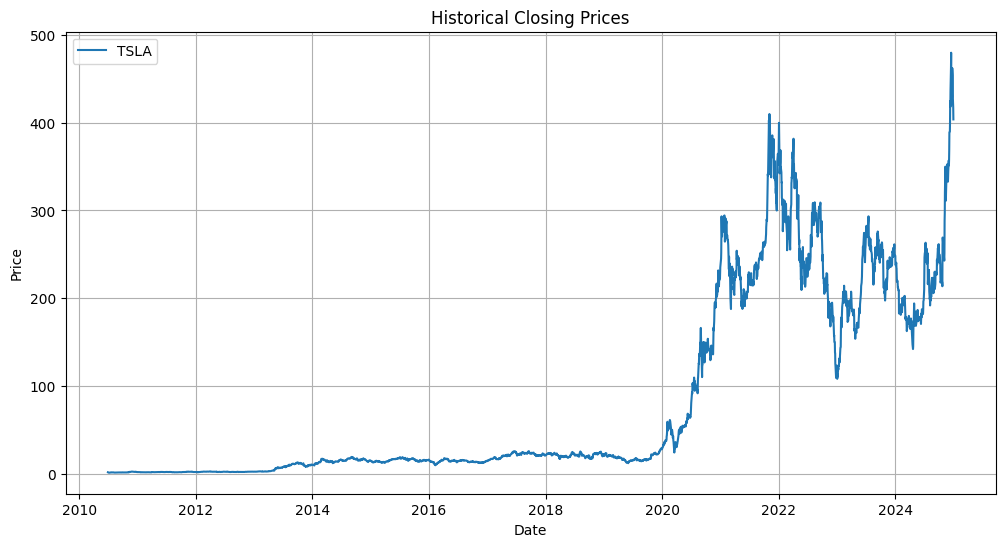

In [6]:
plt.figure(figsize=(12, 6))
plt.plot(tsla['close'], label='TSLA')
plt.title('Historical Closing Prices')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

## 2. Working with Stock Returns

First, let's look at the big picture regarding the types of financial data out there:

1.   **Time Series data**: Data collected over a period of time on one or more variables.
2.   **Cross-sectional data**: Cross-sectional data are data on one or more variables collected at a single point in time.
3. **Panel data**: Panel data have the dimensions of both time series and cross-sections, e.g., the daily prices of a number of blue chip stocks over two years.

Now, let's see how to look at stock returns:

### 2.1 Returns in Financial Modeling

There are two methods used to calculate returns from a series of prices, and these involve the calculation of simple returns or continuously compounded returns. 

- Simple returns:


$R_t = \dfrac{p_t - p_{t-1}}{p_{t-1}} \times 100\%$


- Continuously compounded returns:

    
$r_t = ln \left(\dfrac{p_t}{p_{t-1}}\right) \times 100\%$  

\
(Review)  [Continuous and Discrete compounding.](https://financetrain.com/continuous-and-discrete-compounding)

\
Importantly, these two methods yield different outcomes, which we need to be aware of.

In [7]:
import numpy as np

price_0 = 9  # Imagine this is the price at t=0
price_1 = 10  # Imagine this is the price at t=º

# So, returns for the period t=0 to t=1 will be:

Simple_ret = (price_1 - price_0) / price_0 * 100
Cont_ret = np.log(price_1 / price_0) * 100

print("The simple return at t=1 will be ", "{:.4f}".format(Simple_ret), "%")
print(
    "The continuously compounded return at t=1 will be ", "{:.4f}".format(Cont_ret), "%"
)

The simple return at t=1 will be  11.1111 %
The continuously compounded return at t=1 will be  10.5361 %


### **2.2 Returns: Simple Compounding**

We assume that the asset is purchased at time $t-K$ for price $P_{t-K}$
and then sold $K$ periods later at price $P_t$. 

$$
\begin{equation}
\begin{aligned}
    R_{Kt} & = \dfrac{P_t-P_{t-K}}{P_{t-K}} = \dfrac{P_t}{P_{t-K}}-1 \longrightarrow P_{t}=P_{t-K}(1+R_{t}^{K})
\end{aligned}
\end{equation}
$$
In the case of $K=1$:

$$
\begin{equation}
\begin{aligned}
    R_{t} & = \dfrac{P_t-P_{t-1}}{P_{t-1}} = \dfrac{P_t}{P_{t-1}}-1 \longrightarrow P_{t}=P_{t-1}(1+R_{t})
\end{aligned}
\end{equation}
$$

The max and min values would be:
$$
\begin{equation}
\begin{aligned}
    & min (R_t) = -1 = -100\% \\[6pt]
    & max (R_t) = +\infty
\end{aligned}
\end{equation}
$$

### **2.3 Returns: Using Logs (continuously compounded)**

We assume that the asset is purchased at time $t-K$ for price $P_{t-K}$
and then sold $K$ periods later at price $P_t$. 

$$
\begin{equation}
\begin{aligned}
    r_{t}^{K} & = ln\left( \dfrac{P_t}{P_{t-K}} \right) = ln(P_t) - ln(P_{t-K}) \longrightarrow P_{t}=P_{t-K} \exp{r_{t}^{K}}
\end{aligned}
\end{equation}
$$

In the case of $K=1$:

$$
\begin{equation}
\begin{aligned}
    r_{t} & = ln\left( \dfrac{P_t}{P_{t-1}} \right) = ln(P_t) - ln(P_{t-1}) \longrightarrow P_{t}=P_{t-1} \exp{r_{t}}
\end{aligned}
\end{equation}
$$

The max and min values would be:

$$
\begin{equation}
\begin{aligned}
    & min (R_t) = -\infty\\[6pt]
    & max (R_t) = +\infty
\end{aligned}
\end{equation}
$$


### **2.4 Returns: Properties**

Let's assume that the asset is purchased at time $t-K$ for price $P_{t-K}$
and then sold $K$ periods later at price $P_t$. Then, if we calculate simple
returns for each period, $R_{t} , R_{t+1},\ldots, R_{K}$, the aggregate return over all $K$ periods is:

$$
\begin{equation}
\begin{aligned}
    R_{Kt} & = \dfrac{P_t-P_{t-K}}{P_{t-K}} = \dfrac{P_{t}}{P_{t-K}}-1 = 
    \left[\dfrac{P_t}{P_{t-1}} \times \dfrac{P_{t-1}}{P_{t-2}} \ldots \dfrac{P_{t-K-1}}{P_{t-K}}\right] - 1=\\[6pt]
    & = \left[(1+R_t)(1+R_{t-1})\ldots(1+R_{t-K+1})\right] = \prod_{j=0}^{k-1}(1+R_{t-j})
\end{aligned}
\end{equation}
$$

For Log-returns:

$$
\begin{equation}
\begin{aligned}
    r_{t}^{K} & = ln\left( \dfrac{P_t}{P_{t-K}} \right) = ln(P_t) - ln(P_{t-K})=\\[6pt]
    & = [ln(P_t)-ln(P_{t-1})]+\ldots+[ln(P_{t-(K-1)})-ln(P_{t-K})]
\end{aligned}
\end{equation}
$$


### **2.5 Annualized Returns**

If the asset was held for $k$ years, then the annualized (average) return is defined as:

$$
\begin{equation}
    Annualized \mbox{   } {R_t[k]} = \left[\prod_{j=0}^{k-1}(1+R_{t-j}) \right]^{1/k}-1
\end{equation}
$$

This is a geometric mean of the k one-period simple gross returns involved and can be computed by:

$$
\begin{equation}
    Annualized \mbox{   } {R_t[k]} = \exp{\left[\dfrac{1}{k}\sum_{j=0}^{k-1}ln(1+R_{t-j}) \right]}-1
\end{equation}
$$


**Example: Buffet's Returns - How to use the annualized return**

|  |  |  |  |
|----|----|----|----|
|**Period** |  **Berkshire Hathaway** | **S&P500** | **Annual Outperf.**|
|1960s |  28.3% | 5.0% | 23.3%|
|1970s |  22.2% | 5.9% | 16.3%|
|1980s |  39.1% | 17.3% | 21.7%|
|1990s |  20.5% | 18.0% | 2.5%|
|2000s |  5.9% | -1.0% | 6.8%|
|2010s |  17.9% | 15.3% | 2.6%|
|**1965 - 2014** |  **21.7%** | **9.8%** | **11.8%**|

If you invested 100.000 euros in 1965, what is the amount of money in 2014? (Using the average annual return)


In [8]:
A_ret = 0.217
n_year = 2014 - 1965
Initial_invest = 100000

Total_ret = (1 + A_ret) ** n_year
Final_invest = Initial_invest * Total_ret
print("Your investment will be worth " + str(Final_invest / 10**6) + " millions!")

Your investment will be worth 1510.90908737206 millions!


## 3. Conclusion 

Well done! This has been a quick review of concepts that, hopefully, you were already familiar with.

Now, jump to the next lesson to see a practical investigation of the different properties and stylized facts associated with stock returns.

---
Copyright 2025 WorldQuant University. This
content is licensed solely for personal use. Redistribution or
publication of this material is strictly prohibited.
